In [1]:
import sys
import os
from math import log
import numpy as np
import pandas as pd
import scipy as sp
from PIL import Image
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ReduceLROnPlateau,EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow_addons as tfa

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


# Dataset

Dataset can be found here: https://drive.google.com/drive/folders/1Gh-8q9gR3sL-Phd6GPc69erV2StjTHal?usp=drive_link

* MalImg-dataset-9010 (source: https://www.kaggle.com/datasets/manaswinisunkari/malimg-dataset9010)
* Dataset of 25 malware samples, each converted from their binary representations into 2D grayscale images.
- NOTE: To run the code in this notebook on your own, ensure that you have downloaded the necessary data files and placed them in the appropriate folder structure. If you prefer to store the data files in a different location, make sure to update the file paths in the code accordingly to point to the correct data location.

In [2]:
train_root_path = "data/malimg_dataset/train"
test_root_path = "data/malimg_dataset/validation"

In [3]:
# WARNING - this step loads and preprocesses the images, which can take a while
batches = ImageDataGenerator().flow_from_directory(directory=train_root_path, target_size=(64,64), batch_size=10000)
images, labels = next(batches)

Found 8404 images belonging to 25 classes.


In [4]:
print("Types of Malware in the Dataset: {'malware family': class index}.")
print("25 classes in total\n")
batches.class_indices

Types of Malware in the Dataset: {'malware family': class index}.
25 classes in total



{'Adialer.C': 0,
 'Agent.FYI': 1,
 'Allaple.A': 2,
 'Allaple.L': 3,
 'Alueron.gen!J': 4,
 'Autorun.K': 5,
 'C2LOP.P': 6,
 'C2LOP.gen!g': 7,
 'Dialplatform.B': 8,
 'Dontovo.A': 9,
 'Fakerean': 10,
 'Instantaccess': 11,
 'Lolyda.AA1': 12,
 'Lolyda.AA2': 13,
 'Lolyda.AA3': 14,
 'Lolyda.AT': 15,
 'Malex.gen!J': 16,
 'Obfuscator.AD': 17,
 'Rbot!gen': 18,
 'Skintrim.N': 19,
 'Swizzor.gen!E': 20,
 'Swizzor.gen!I': 21,
 'VB.AT': 22,
 'Wintrim.BX': 23,
 'Yuner.A': 24}

In [5]:
print("Dimensions of the dataset. 8445 images, each is of size 64x64 pixels with 3 channels")
images.shape

Dimensions of the dataset. 8445 images, each is of size 64x64 pixels with 3 channels


(8404, 64, 64, 3)

## Malware as Images

We can visualise the malware samples by plotting the images themselves. We can see that for different malware samples within the same family, the image textures look very similar.

In [6]:
def plot_images(images, figsize=(20,30), rows=10, interp=False, titles=None):
    if type(images[0]) is np.ndarray:
        images = np.array(images).astype(np.uint8)
        if (images.shape[-1] != 3):
            images = images.transpose((0,2,3,1))
    f = plt.figure(figsize=figsize)
    cols = 10
    for i in range(0,100):
        sp = f.add_subplot(rows, cols, i+1)
        sp.axis('Off')
        if titles is not None:
            sp.set_title(f"{i}: {list(batches.class_indices.keys())[np.argmax(titles[i])]}", fontsize=14)
        plt.imshow(images[i], interpolation=None if interp else 'none')

Visualising the first 100 images (malware samples) in the dataset.



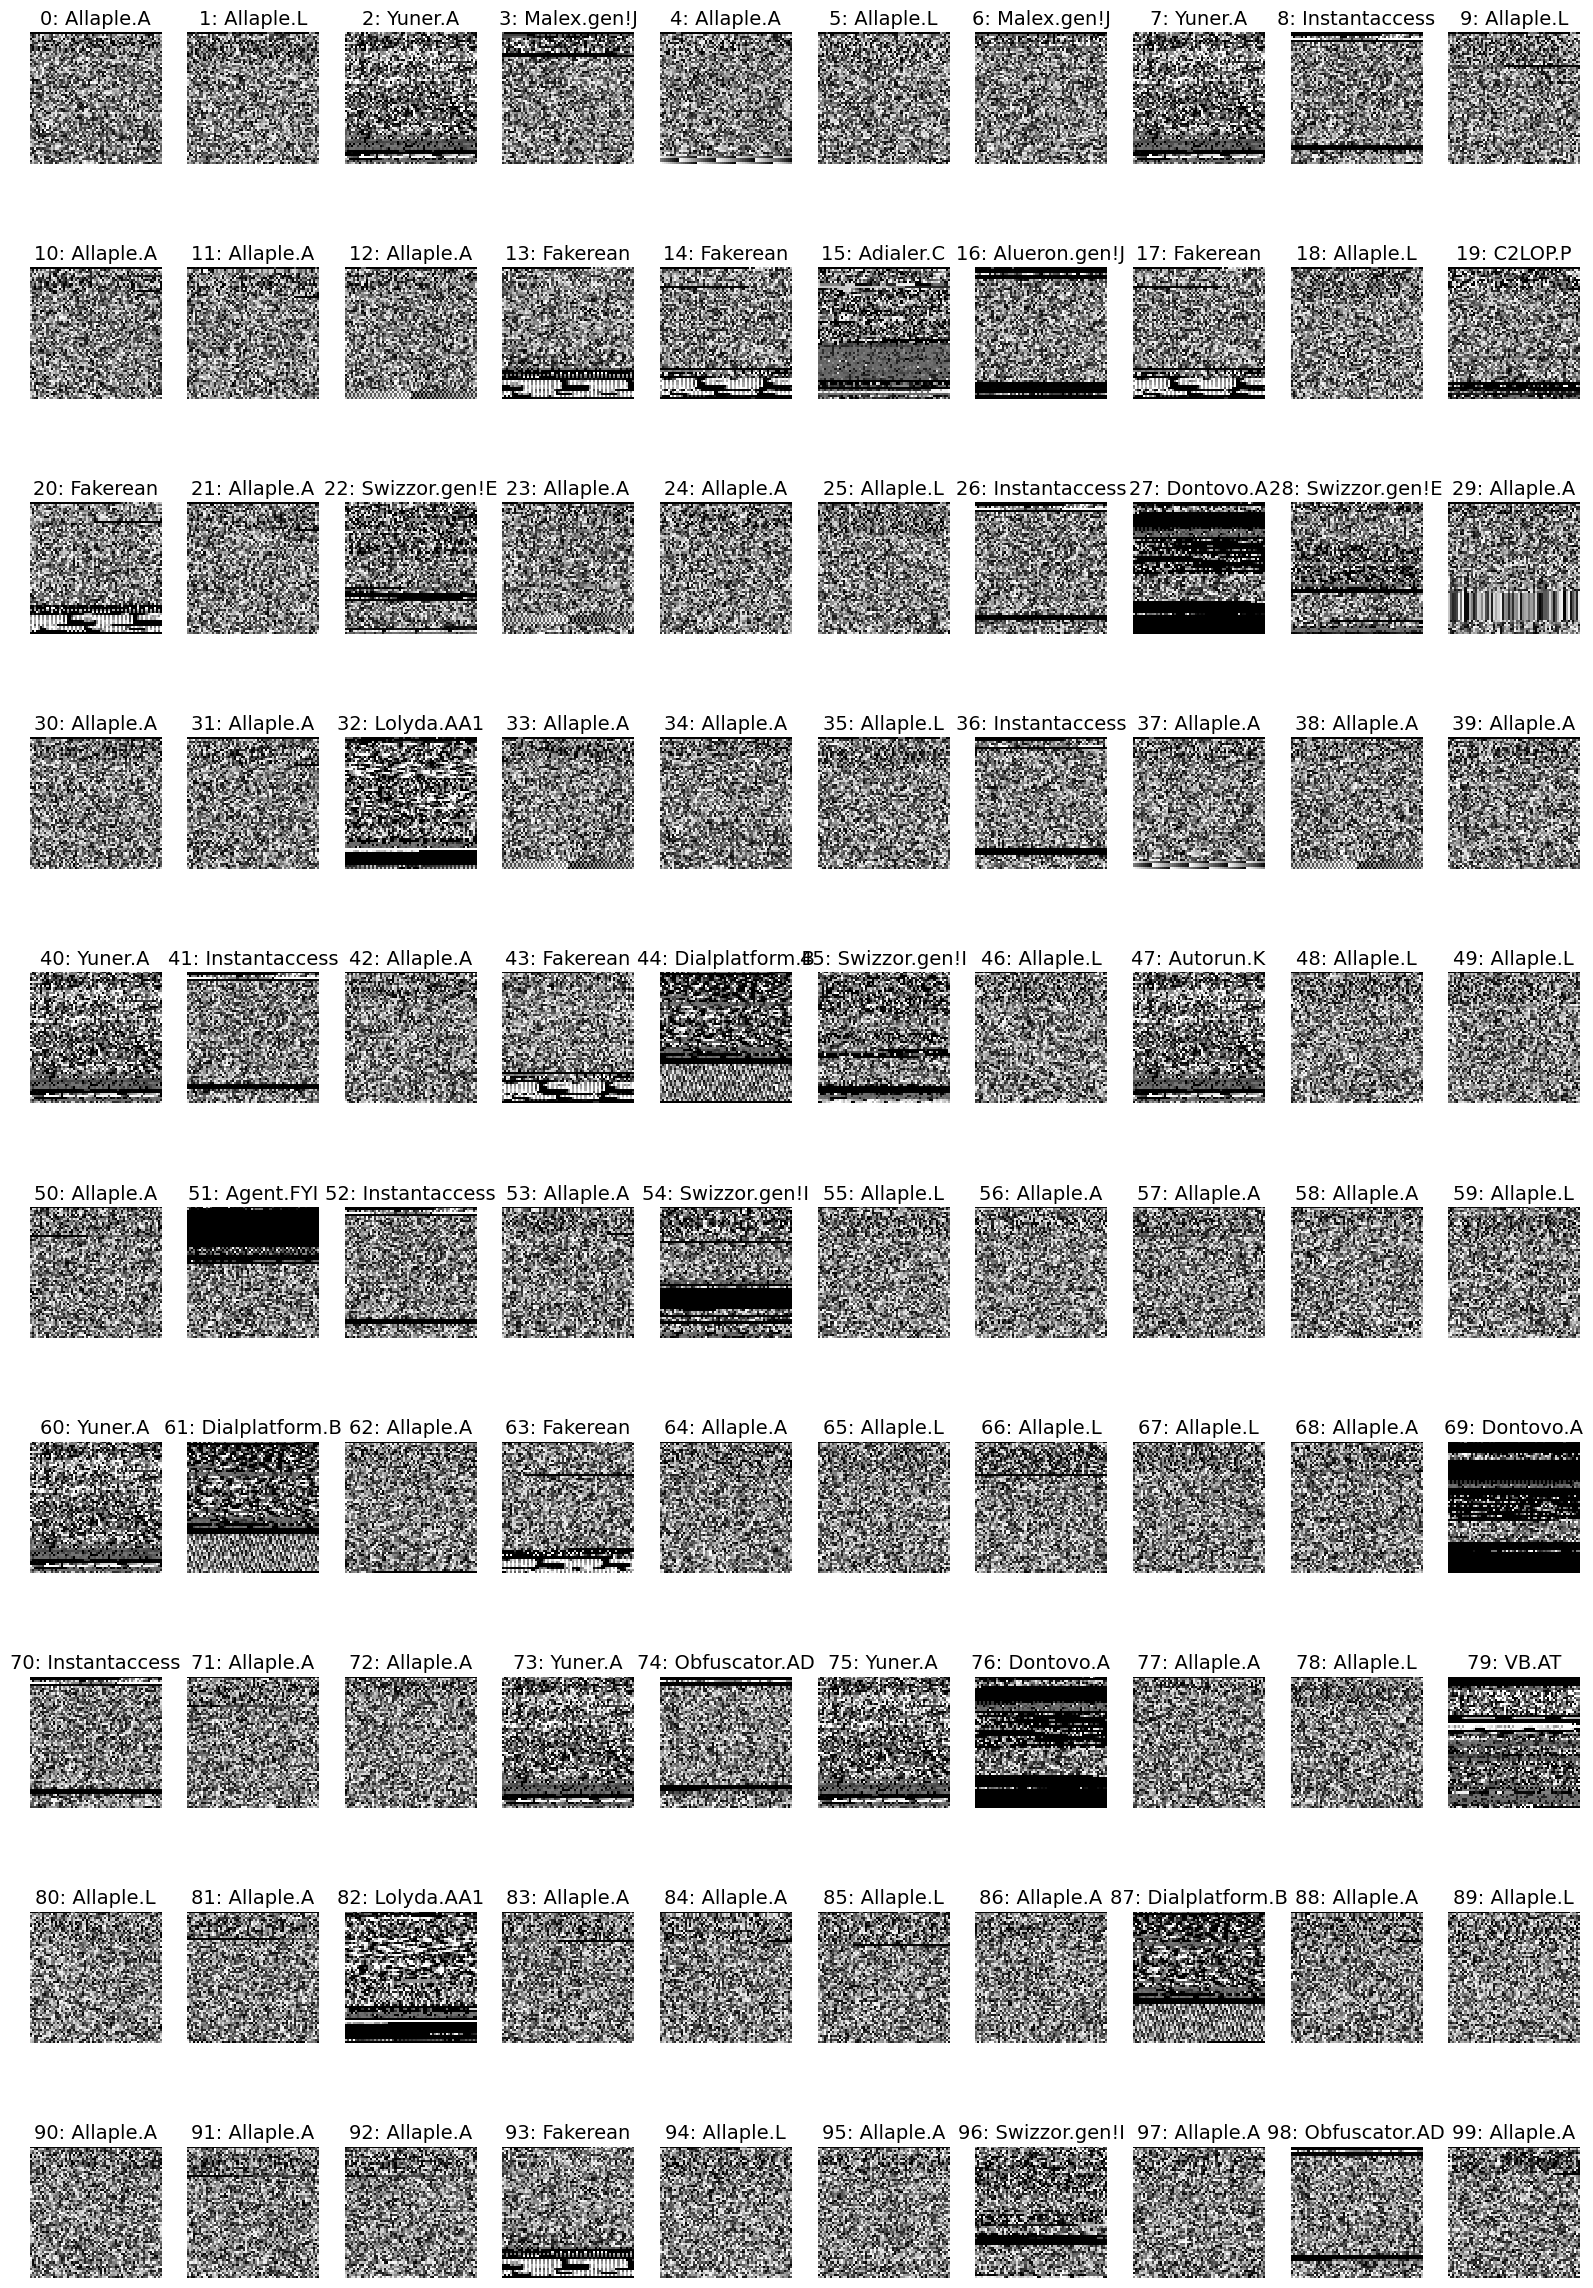

In [7]:
print("Visualising the first 100 images (malware samples) in the dataset.\n")
plot_images(images, titles=labels)

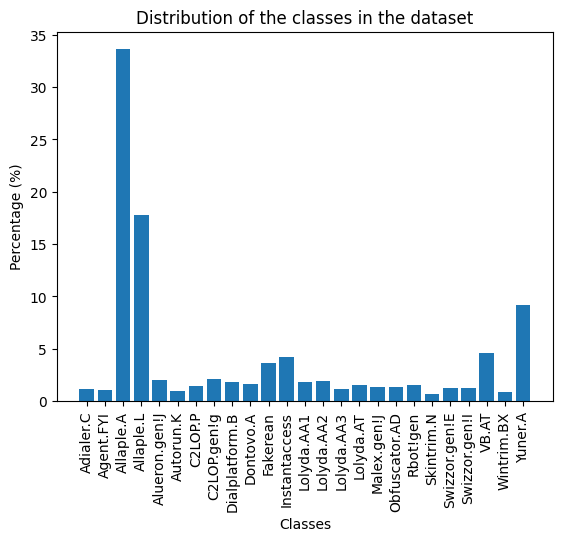

In [8]:
classes = batches.class_indices.keys()
perc = (sum(labels)/labels.shape[0])*100
plt.xticks(rotation='vertical')
plt.bar(classes, perc)
plt.title("Distribution of the classes in the dataset")
plt.xlabel("Classes")
plt.ylabel("Percentage (%)")
plt.show()

In [9]:
print("Separating data into training and testing sets")
x_train, x_test, y_train, y_test = train_test_split(images/255., labels, test_size=0.3)

Separating data into training and testing sets


In [10]:
print(f"x_train shape: {x_train.shape} - y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape} - y_test shape: {y_test.shape}")

x_train shape: (5882, 64, 64, 3) - y_train shape: (5882, 25)
x_test shape: (2522, 64, 64, 3) - y_test shape: (2522, 25)


# Deep Learning Models

Here we perform the malware detection using 3 deep learning models.
- Feed-forward Neural Network (FFNN)
- Convolutional Neural Network (CNN)
- Convolution with Self-Attention Network (CoAtNet)

FFNNs and CNNs often serve as baseline models in research. The CoAtNet is a near state-of-the-art model developed by Google. We expect to see better performance by the CoAtNet than either FFNN or CNN.

In [11]:
num_classes = len(classes)
input_shape = (64, 64, 3) # dimensions of each input (each sample) into our models

# FFNN Model

* FFNNs are the simplest type of artificial neural network where information flows in one direction from input to output layers.
* An FFNN consists of an input layer, one or more hidden layers, and an output layer. Each layer is made up of nodes or neurons. The nodes in one layer are connected to the nodes in the next layer by weighted connections.
* Data enters the network through the input layer, gets mathematically transformed as it passes through the hidden layers, and the final result is produced by the output layer. This one-way flow of information from input to output gives FFNNs their name.

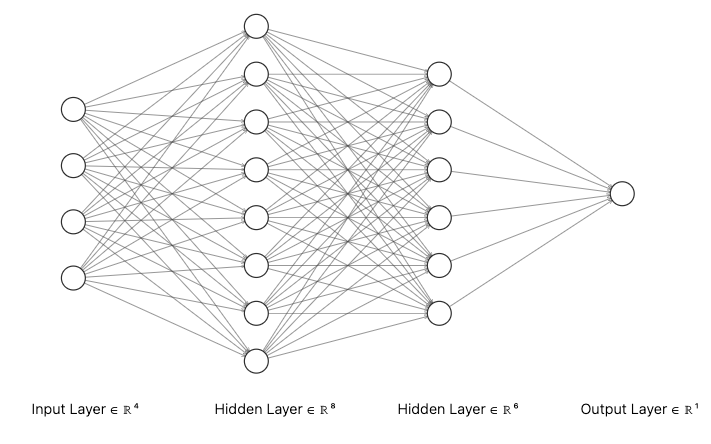

In [12]:
# Define the FFNN model
model = keras.Sequential([
    layers.Input(shape=input_shape),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=1e-3),
    metrics=[
        keras.metrics.CategoricalAccuracy(name="accuracy"),
        keras.metrics.TopKCategoricalAccuracy(5, name="top-5-accuracy"),
    ],
)

# Train the model
model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=40,
    validation_split=0.1,
    verbose=1,
    callbacks=[
        keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', patience=4, verbose=1, factor=0.4, min_lr=0.0001),
        keras.callbacks.EarlyStopping(monitor='val_accuracy', min_delta=0.00001, patience=8, mode='auto', restore_best_weights=True)
    ]
)


2024-05-10 21:40:11.761560: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2024-05-10 21:40:11.761579: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2024-05-10 21:40:11.761596: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2024-05-10 21:40:11.761626: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2024-05-10 21:40:11.761639: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/40


2024-05-10 21:40:12.448787: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2024-05-10 21:40:12.476408: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


42/42 [==============================] - 2s 25ms/step - loss: 55.6640 - accuracy: 0.2562 - top-5-accuracy: 0.5664 - val_loss: 43.0112 - val_accuracy: 0.4211 - val_top-5-accuracy: 0.8081 - lr: 0.0010
Epoch 2/40
42/42 [==============================] - 1s 19ms/step - loss: 51.3909 - accuracy: 0.3542 - top-5-accuracy: 0.6503 - val_loss: 38.1191 - val_accuracy: 0.4312 - val_top-5-accuracy: 0.8285 - lr: 0.0010
Epoch 3/40
42/42 [==============================] - 1s 18ms/step - loss: 39.6714 - accuracy: 0.4264 - top-5-accuracy: 0.7077 - val_loss: 22.7338 - val_accuracy: 0.6350 - val_top-5-accuracy: 0.8370 - lr: 0.0010
Epoch 4/40
42/42 [==============================] - 1s 19ms/step - loss: 31.5282 - accuracy: 0.5111 - top-5-accuracy: 0.7667 - val_loss: 22.8875 - val_accuracy: 0.5823 - val_top-5-accuracy: 0.8862 - lr: 0.0010
Epoch 5/40
42/42 [==============================] - 1s 19ms/step - loss: 26.2171 - accuracy: 0.5643 - top-5-accuracy: 0.7982 - val_loss: 20.3961 - val_accuracy: 0.6706 - v

In [13]:
loss_ffnn, acc_ffnn, _, = model.evaluate(x_test, y_test)
print("FFNN Model Performance")
print(f"Test loss: {loss_ffnn:.5f}")
print(f"Test accuracy: {acc_ffnn * 100:.2f}%")

79/79 [==============================] - 1s 10ms/step - loss: 7.6567 - accuracy: 0.8731 - top-5-accuracy: 0.9711
FFNN Model Performance
Test loss: 7.65673
Test accuracy: 87.31%


# CNN Model

* A convolutional neural network (CNN) is a type of deep learning model specifically designed for processing grid-like data, such as images. CNNs are inspired by the structure and function of the human visual cortex and have revolutionized the field of computer vision.
* A CNN consists of multiple layers, including convolutional layers, pooling layers, and fully connected layers. These layers work together to automatically learn and extract relevant features from the input data.
  * Convolutional layers: These layers use small grids called filters or kernels that slide over the input image. Each filter is designed to detect specific patterns or features, such as edges, curves, or shapes. As the filter moves across the image, it creates a new grid that highlights where it found these patterns.
  * Pooling layers: Pooling layers reduce the spatial dimensions of the feature maps produced by the convolutional layers. This helps to reduce the number of parameters and computations in the network, as well as provide a degree of translation invariance.
  * Fully connected layers: After the convolutional and pooling layers have extracted relevant features, the output is flattened and passed through one or more fully connected layers. These layers perform the final classification or regression task based on the learned features.

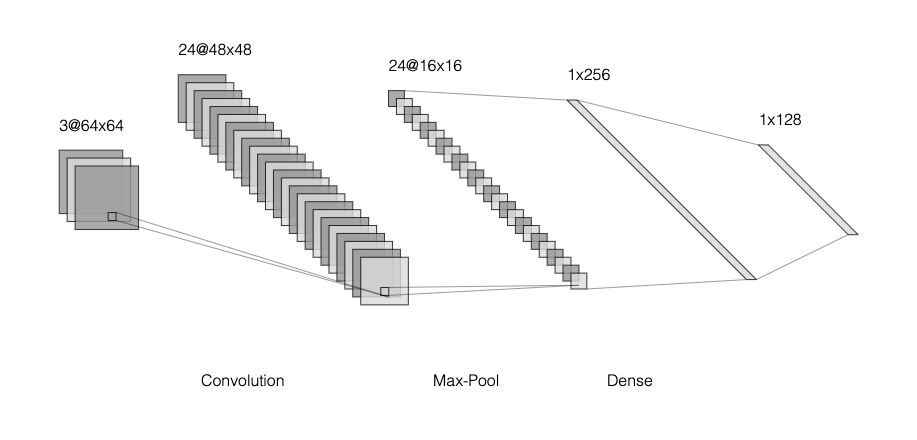

In [14]:
# Define the CNN model
model = keras.Sequential([
    layers.Input(shape=input_shape),
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(128, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=1e-3),
    metrics=[
        keras.metrics.CategoricalAccuracy(name="accuracy"),
        keras.metrics.TopKCategoricalAccuracy(5, name="top-5-accuracy"),
    ],
)

# Train the model
model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=40,
    validation_split=0.1,
    verbose=1,
    callbacks=[
        keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', patience=4, verbose=1, factor=0.4, min_lr=0.0001),
        keras.callbacks.EarlyStopping(monitor='val_accuracy', min_delta=0.00001, patience=8, mode='auto', restore_best_weights=True)
    ]
)

Epoch 1/40
42/42 [==============================] - 4s 45ms/step - loss: 2.3207 - accuracy: 0.3916 - top-5-accuracy: 0.7470 - val_loss: 1.6067 - val_accuracy: 0.5874 - val_top-5-accuracy: 0.8812 - lr: 0.0010
Epoch 2/40
42/42 [==============================] - 1s 26ms/step - loss: 1.6339 - accuracy: 0.6391 - top-5-accuracy: 0.9127 - val_loss: 1.2066 - val_accuracy: 0.8098 - val_top-5-accuracy: 0.9694 - lr: 0.0010
Epoch 3/40
42/42 [==============================] - 1s 29ms/step - loss: 1.3027 - accuracy: 0.8154 - top-5-accuracy: 0.9613 - val_loss: 1.0014 - val_accuracy: 0.9304 - val_top-5-accuracy: 0.9915 - lr: 0.0010
Epoch 4/40
42/42 [==============================] - 1s 26ms/step - loss: 1.1795 - accuracy: 0.8810 - top-5-accuracy: 0.9770 - val_loss: 0.9493 - val_accuracy: 0.9321 - val_top-5-accuracy: 0.9932 - lr: 0.0010
Epoch 5/40
42/42 [==============================] - 1s 26ms/step - loss: 1.0618 - accuracy: 0.9055 - top-5-accuracy: 0.9847 - val_loss: 0.9159 - val_accuracy: 0.9406 - 

In [15]:
loss_cnn, acc_cnn, _, = model.evaluate(x_test, y_test)
print("CNN Model Performance")
print(f"Test loss: {loss_cnn:.5f}")
print(f"Test accuracy: {acc_cnn * 100:.2f}%")

79/79 [==============================] - 1s 13ms/step - loss: 0.7958 - accuracy: 0.9715 - top-5-accuracy: 0.9980
CNN Model Performance
Test loss: 0.79579
Test accuracy: 97.15%


# CoAtNet Model

* CoAtNet is a new type of neural network that combines the best aspects of two popular architectures - convolutional neural networks (CNNs) and Transformers.
* CNNs are good at processing visual patterns and extracting local features, but can't easily model long-range dependencies. Transformers use self-attention to capture global interactions, but lack some of the useful inductive biases of convolutions.
* CoAtNet integrates convolutions and attention in a clever way:
  * It unifies depthwise convolution and self-attention into a single "relative attention" operation. This brings together the local pattern recognition of convolutions and global information aggregation of attention.
  * It stacks convolution layers and attention layers vertically in multiple stages. The convolution layers in early stages process low-level visual features, while attention layers in later stages capture high-level semantic concepts. This arrangement improves both efficiency and generalization.

In [16]:
# WARNING - depending on your system, this might take a long time to run

from keras_cv_attention_models import coatnet

# Define the CoAtNet model
model = coatnet.CoAtNet0(
    input_shape=input_shape,
    num_classes=num_classes,
    drop_connect_rate=0.2,
    classifier_activation="softmax")

# Compile the model
model.compile(
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    optimizer=keras.optimizers.Adam(learning_rate=1e-3, weight_decay=0.0001),
    metrics=[
        keras.metrics.CategoricalAccuracy(name="accuracy"),
        keras.metrics.TopKCategoricalAccuracy(5, name="top-5-accuracy"),
    ],
)

# Train the model
model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=40,
    validation_split=0.1,
    verbose=1,
    callbacks=[
        keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', patience=4, verbose=1, factor=0.4, min_lr=0.0001),
        keras.callbacks.EarlyStopping(monitor='val_accuracy', min_delta=0.00001, patience=8, mode='auto', restore_best_weights=True)
    ]
)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[Error] will not load weights, url not found or download failed: https://github.com/leondgarse/keras_cv_attention_models/releases/download/coatnet/coatnet0_160_imagenet.h5
Epoch 1/40
42/42 [==============================] - 106s 2s/step - loss: 27.1820 - accuracy: 0.1955 - top-5-accuracy: 0.4330 - val_loss: 17.5046 - val_accuracy: 0.3056 - val_top-5-accuracy: 0.5891 - lr: 0.0010
Epoch 2/40
42/42 [==============================] - 71s 2s/step - loss: 6.1806 - accuracy: 0.4243 - top-5-accuracy: 0.7712 - val_loss: 2.0083 - val_accuracy: 0.5942 - val_top-5-accuracy: 0.8964 - lr: 0.0010
Epoch 3/40
42/42 [==============================] - 61s 1s/step - loss: 1.6411 - accuracy: 0.6401 - top-5-accuracy: 0.9375 - val_loss: 1.5054 - val_accuracy: 0.7216 - val_top-5-accuracy: 0.9694 - lr: 0.0010
Epoch 4/40
42/42 [==============================] - 63s 1s/step - loss: 1.4122 - accuracy: 0.7419 - top-5-accuracy: 0.9637 - val_loss: 1.8699 - val_accuracy: 0.6859 - val_top-5-accuracy: 0.9677 - lr: 0.00

In [17]:
loss_coat, acc_coat, _, = model.evaluate(x_test, y_test)
print("CoAtNet Model Performance")
print(f"Test loss: {loss_coat:.5f}")
print(f"Test accuracy: {acc_coat * 100:.2f}%")

79/79 [==============================] - 11s 107ms/step - loss: 0.7127 - accuracy: 0.9818 - top-5-accuracy: 0.9992
CoAtNet Model Performance
Test loss: 0.71275
Test accuracy: 98.18%


# Visualise CoAtNet Misclassifications

Another perspective on model performance is to look at what your model got right and/or wrong. We can visualise this using a confusion matrix which compares the true labels vs. predicted labels for a multi-class classification model. The matrix has a row and column for each class. Diagonal elements show correct predictions, while off-diagonal elements indicate misclassifications between classes.

In [18]:
pred_x = model.predict(x_test, verbose=0)
y_pred=np.argmax(pred_x,axis=1)
y_test_argmaxed = np.argmax(y_test, axis=1)

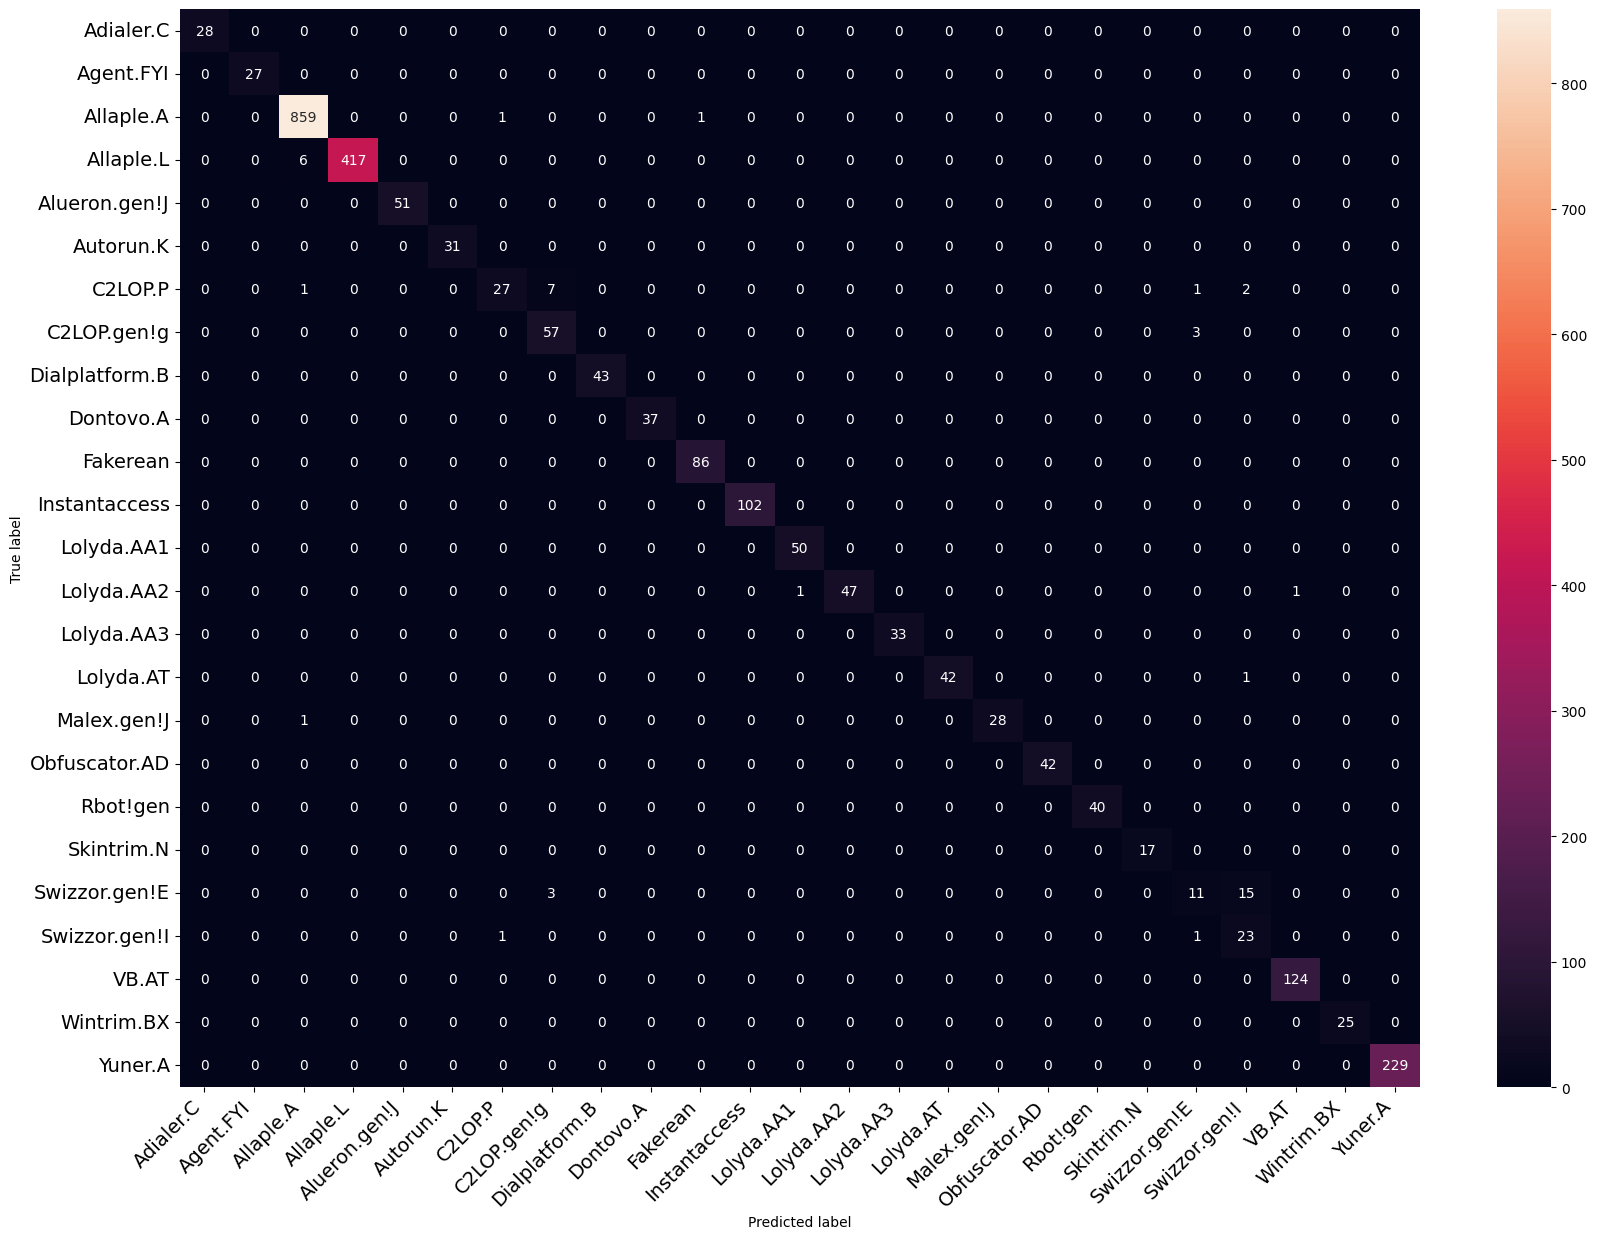

In [19]:
from sklearn import metrics
import seaborn as sns

def confusion_matrix(confusion_matrix, class_names, figsize = (10,10), fontsize=14):
    df_cm = pd.DataFrame(
        confusion_matrix, index=class_names, columns=class_names,
    )
    fig = plt.figure(figsize=figsize)
    try:
        heatmap = sns.heatmap(df_cm, annot=True, fmt="d")
    except ValueError:
        raise ValueError("Confusion matrix values must be integers.")
    heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=0, ha='right', fontsize=fontsize)
    heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=45, ha='right', fontsize=fontsize)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

c_matrix = metrics.confusion_matrix(y_test_argmaxed, y_pred)
class_names= batches.class_indices.keys()
confusion_matrix(c_matrix, class_names, figsize = (20,14), fontsize=14)